# AlignMMBench 批量推理

本笔记本使用 `qwen3smvl/inference/inference_vl_model.py` 中的 `run_inference` 函数
对 **AlignMMBench** 数据集进行批量推理，并将结果保存到 `inference_result/` 目录。

| 节 | 内容 |
|---|---|
| 0 | 环境检查与路径配置 |
| 1 | 推理参数配置 |
| 2 | 执行批量推理 |
| 3 | 查看与分析推理结果 |

## 0. 环境检查与路径配置

In [1]:
import sys
import os

print('Python executable:', sys.executable)
print('Python version   :', sys.version.split()[0])

# ── 确保项目根目录在 sys.path 中，使 qwen3smvl 包可被导入 ──────────────────────
# 笔记本位于 <project_root>/notebooks/，需上移一级才能到达项目根目录
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'Project root     : {PROJECT_ROOT}')

try:
    import transformers, accelerate
    print(f'transformers     : {transformers.__version__}')
    print(f'accelerate       : {accelerate.__version__}')
    print('Import check     : OK')
    from transformers import AutoProcessor
except Exception as e:
    print('Import check     : FAIL →', type(e).__name__, e)
    print('\n→ Kernel 未使用项目 .venv，请在右上角内核选择器中切换为')
    print('  .venv\\Scripts\\python.exe')

Python executable: e:\cursorprojects\Qwen3-SmVL\.venv\Scripts\python.exe
Python version   : 3.12.13
Project root     : e:\cursorprojects\Qwen3-SmVL


e:\cursorprojects\Qwen3-SmVL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\cursorprojects\Qwen3-SmVL\.venv\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


transformers     : 4.56.2
accelerate       : 1.10.1
Import check     : OK


In [2]:
import logging
import json
from pathlib import Path

# ── 日志配置：INFO 级别，方便观察推理进度 ─────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s - %(message)s',
    datefmt='%H:%M:%S'
)

# ── 导入核心推理函数 ────────────────────────────────────────────────────────
from qwen3smvl.inference.inference_vl_model import run_inference

print('run_inference 导入成功')

run_inference 导入成功


## 1. 推理参数配置

在此单元格中统一配置所有路径与超参数，方便快速调整而无需修改其他代码。

In [ ]:
import torch

# ── 模型路径 ───────────────────────────────────────────────────────────────
# 指向本地已训练/下载的模型检查点目录
# 如需使用其他检查点，直接修改此变量即可
# CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "model", "full_tuning")
CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "model", "unfreeze_connector_pretraining_full")
# CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "model", "Qwen3.5-0.8B")

#用于处理数据的processor
# _PROC_PATH = os.path.join(PROJECT_ROOT, "model", "Qwen3.5-0.8B")
# PROCESSOR = AutoProcessor.from_pretrained(
#         _PROC_PATH
#     )
PROCESSOR = None

# ── AlignMMBench 数据集路径 ────────────────────────────────────────────────
# metadata.jsonl 每行包含：question_id, image_path, prompt, ref_answer 等字段
JSONL_PATH  = os.path.join(PROJECT_ROOT, "data", "AlignMMBench", "metadata.jsonl")
# 图像根目录（image_path 字段的相对路径以此为基准）
IMAGE_ROOT  = os.path.join(PROJECT_ROOT, "data", "AlignMMBench")

# ── 输出目录与文件 ─────────────────────────────────────────────────────────
# 推理结果保存到项目根目录下的 inference_result/ 文件夹
OUTPUT_DIR  = os.path.join(PROJECT_ROOT, "inference_result")
OUTPUT_PATH = os.path.join(OUTPUT_DIR, "connector_pretraining_full_alignmmbench_predictions.jsonl")
# OUTPUT_PATH = os.path.join(OUTPUT_DIR, "full_tuning_alignmmbench_predictions.jsonl")
# OUTPUT_PATH = os.path.join(OUTPUT_DIR, "qwen3.5_alignmmbench_predictions.jsonl")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 连接器形状日志（可选）─────────────────────────────────────────────────
# 设为空串时使用默认路径（temp/image_token_length.csv）；
# 设为 None 可传入 VLModelInference 以禁用 CSV 记录（enable_csv=False）
# CSV_PATH = os.path.join(PROJECT_ROOT, "temp", "image_token_length_alignmmbench.csv")
CSV_PATH = None

# ── 推理超参数 ─────────────────────────────────────────────────────────────
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE     = 8        # 每批处理的样本数；显存不足时可调小（如 2 或 4）
MAX_NEW_TOKENS = 2048      # 模型单次最多生成的 token 数
TEMPERATURE    = 0.7      # 采样温度：越高输出越多样，越低越保守
TOP_P          = 0.9      # top-p 核采样参数
SYSTEM_PROMPT  = "你是一个有帮助的语言与视觉助手。你能够理解用户提供的视觉内容，并使用自然语言协助用户完成各种任务。"  # 注入对话首部的 system 消息
ENABLE_THINKING = False   # 是否启用 <think>…</think> 思考模式
# 是否在用户消息中注入图像介绍 / 结尾文字（与训练 collator 同名参数对齐）。
# 仅当训练阶段也开启了该选项时才应设为 True，否则会与训练分布出现偏差。
ADD_MEDIA_INTRO_OUTRO = True
MAX_SAMPLES    = 16     # 参与推理的最大样本数；设为 None 表示使用全部样本
                          # 调试时可设为小值（如 16）快速验证流程

print(f"设备           : {DEVICE}")
print(f"模型检查点     : {CHECKPOINT_PATH}")
print(f"数据集 JSONL   : {JSONL_PATH}")
print(f"图像根目录     : {IMAGE_ROOT}")
print(f"输出文件       : {OUTPUT_PATH}")
print(f"批大小         : {BATCH_SIZE}")
print(f"最大样本数     : {MAX_SAMPLES if MAX_SAMPLES else '全部'}")

# 检查关键路径是否存在，提前发现配置错误
assert os.path.exists(CHECKPOINT_PATH), f"检查点不存在: {CHECKPOINT_PATH}"
assert os.path.exists(JSONL_PATH),      f"JSONL 文件不存在: {JSONL_PATH}"
assert os.path.exists(IMAGE_ROOT),      f"图像根目录不存在: {IMAGE_ROOT}"
print("\n路径检查通过 ✓")

设备           : cuda
模型检查点     : e:\cursorprojects\Qwen3-SmVL\model\Qwen3.5-0.8B
数据集 JSONL   : e:\cursorprojects\Qwen3-SmVL\data\AlignMMBench\metadata.jsonl
图像根目录     : e:\cursorprojects\Qwen3-SmVL\data\AlignMMBench
输出文件       : e:\cursorprojects\Qwen3-SmVL\inference_result\qwen3.5_alignmmbench_predictions.jsonl
批大小         : 8
最大样本数     : 16

路径检查通过 ✓


## 2. 执行批量推理

`run_inference` 函数会：
1. 加载模型与处理器
2. 按 `BATCH_SIZE` 分批处理所有样本
3. 每处理 100 条样本进行一次增量保存，防止意外中断丢失结果
4. 推理结束后将全部结果写入 `OUTPUT_PATH`（JSONL 格式，每行一条）

In [4]:
run_inference(
    model_or_checkpoint_path=CHECKPOINT_PATH,
    processor=PROCESSOR,
    output_path=OUTPUT_PATH,
    jsonl_path=JSONL_PATH,
    image_root=IMAGE_ROOT,
    csv_path=CSV_PATH,
    batch_size=BATCH_SIZE,
    max_new_tokens=MAX_NEW_TOKENS,
    temperature=TEMPERATURE,
    top_p=TOP_P,
    system_prompt=SYSTEM_PROMPT,
    enable_thinking=ENABLE_THINKING,
    # 与训练 collator 的同款 add_media_intro_outro 行为对齐
    add_media_intro_outro=ADD_MEDIA_INTRO_OUTRO,
    max_samples=MAX_SAMPLES,
    device=DEVICE,
)

17:10:42 [INFO] qwen3smvl.inference.inference_vl_model - Loading dataset from e:\cursorprojects\Qwen3-SmVL\data\AlignMMBench\metadata.jsonl...
17:10:42 [INFO] qwen3smvl.inference.inference_vl_model - Loaded 16 samples
17:10:42 [INFO] qwen3smvl.inference.inference_vl_model - 正在加载训练后的模型: e:\cursorprojects\Qwen3-SmVL\model\Qwen3.5-0.8B
17:10:42 [INFO] qwen3smvl.utils - 正在加载SmolVLM2视觉-语言模型...
`torch_dtype` is deprecated! Use `dtype` instead!
17:10:43 [INFO] qwen3smvl.utils - 正在加载Qwen3语言模型...
17:10:44 [INFO] qwen3smvl.utils - 正在构建连接器配置...
17:10:44 [INFO] qwen3smvl.utils - 正在创建新的连接器...
17:10:44 [INFO] qwen3smvl.utils - 正在替换语言模型组件...
17:10:44 [INFO] qwen3smvl.utils - 正在更新模型配置...
17:10:44 [INFO] qwen3smvl.utils - 模型构建完成！
17:10:44 [INFO] qwen3smvl.inference.inference_vl_model - 使用调用方提供的自定义 processor，跳过 load_processor()
17:10:44 [WARNING] qwen3smvl.inference.inference_vl_model - ⚠️  未找到权重文件，使用原始模型
17:10:44 [INFO] qwen3smvl.inference.inference_vl_model - 
Running inference on 16 samples with batc

## 3. 查看与分析推理结果

推理完成后，从输出文件中读取结果并结合原始数据集进行对比展示。

In [5]:
# ── 读取推理结果 ──────────────────────────────────────────────────────────
results = []
with open(OUTPUT_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            results.append(json.loads(line))

print(f"共读取 {len(results)} 条推理结果")
print("\n前 3 条原始结果：")
for r in results[:3]:
    print(r)

共读取 16 条推理结果

前 3 条原始结果：
{'question_id': '00000000-0', 'predict': '两个卡通人物，左侧是身穿蓝色制服的主角，右侧是穿着白色裤子、红色袖口的配角角色，背景为橙色和黄色。上方写着“英雄”和“勇士”，下方显示“拯救世界”。########################################################################################################'}
{'question_id': '00000000-1', 'predict': '两个卡通角色，左侧是穿着蓝色衣服的男孩（漫画人物）和一个戴着红色帽子的小孩，右侧是穿白色裤子的男婴，旁边有一行文字“上帝救赎”。###############################################################################################################'}
{'question_id': '00000000-2', 'predict': '两个卡通人物，左侧是身穿蓝衣服的英雄形象（穿着战袍），右侧是穿白大褂的小人角色（拿着工具）。背景为橙色调。文字“勇敢者”和“智者”的下方分别标注了两人的姓名。每个角色都戴着红领巾或盾牌。左上角有一个简体中文字块：“勇者”。右下角还有一个简码汉字字符：“智士”。##############################################################'}


[1/5] question_id : 00000000-0
  category   : Perception & Understanding
  task       : Description
  prompt     : 描述图片。
  prediction : 两个卡通人物，左侧是身穿蓝色制服的主角，右侧是穿着白色裤子、红色袖口的配角角色，背景为橙色和黄色。上方写着“英雄”和“勇士”，下方显示“拯救世界”。########################################################################################################
  ref_answer : 这张图片展现了完成超高强度的训练之后的理想和现实之间的对比。理想中的样子是超人，而现实中的样子是拄着拐杖残疾的人，运用了夸张的对比，表达出了理想和现实之间的差别，非常的幽默和诙谐，也真实的反映了实际情况。图片下方有一个跑步的图案，旁边写有英文“RUNNING BIBLE”。


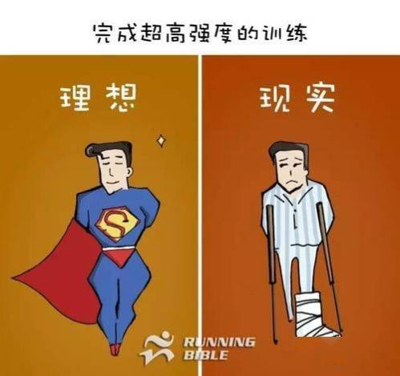


[2/5] question_id : 00000000-1
  category   : Perception & Understanding
  task       : Description
  prompt     : 请描述这张图片的内容。
  prediction : 两个卡通角色，左侧是穿着蓝色衣服的男孩（漫画人物）和一个戴着红色帽子的小孩，右侧是穿白色裤子的男婴，旁边有一行文字“上帝救赎”。###############################################################################################################
  ref_answer : 这张图片展现了完成超高强度的训练之后的理想和现实之间的对比。理想中的样子是超人，而现实中的样子是拄着拐杖残疾的人，运用了夸张的对比，表达出了理想和现实之间的差别，非常的幽默和诙谐，也真实的反映了实际情况。图片下方有一个跑步的图案，旁边写有英文“RUNNING BIBLE”。


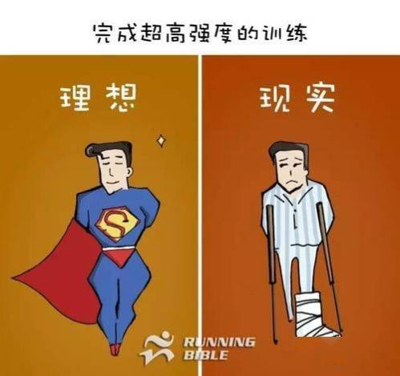


[3/5] question_id : 00000000-2
  category   : Perception & Understanding
  task       : Description
  prompt     : 请描述这张图片展现的情景。
  prediction : 两个卡通人物，左侧是身穿蓝衣服的英雄形象（穿着战袍），右侧是穿白大褂的小人角色（拿着工具）。背景为橙色调。文字“勇敢者”和“智者”的下方分别标注了两人的姓名。每个角色都戴着红领巾或盾牌。左上角有一个简体中文字块：“勇者”。右下角还有一个简码汉字字符：“智士”。##############################################################
  ref_answer : 这张图片展现了完成超高强度的训练之后的理想和现实之间的对比。理想中的样子是超人，而现实中的样子是拄着拐杖残疾的人，运用了夸张的对比，表达出了理想和现实之间的差别，非常的幽默和诙谐，也真实的反映了实际情况。图片下方有一个跑步的图案，旁边写有英文“RUNNING BIBLE”。


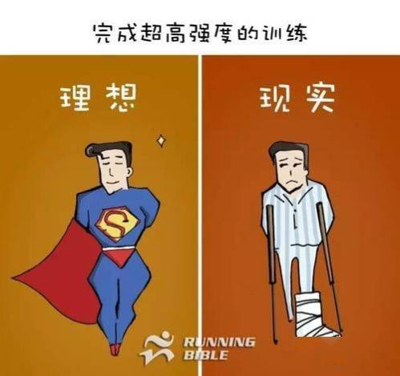


[4/5] question_id : 00000000-3
  category   : Perception & Understanding
  task       : Description
  prompt     : 这张图片上有什么元素？请详细说明。
  prediction : 两个卡通形象，左边是超级英雄角色，右边是普通人物，背景为橙色和白色渐变背景。左侧穿着蓝色制服，手持盾牌；右侧穿白大褂，拿着拐杖。文字“超人”和“普通人”并列于画面中央。左方的图形显示为黄色、红色或绿色闪电图案，右方则是黑色或灰色轮廓线。两者通过箭头连接，形成对比。文中标注了“超级人类”、“普通人类”的标题。安全提示中包含警告信息。图像由动画制作公司Epic Games提供。图标风格偏向漫画风。图中的数字2019年版本已更新至最新版。当前时间为23:45（北京时间）。
  ref_answer : 这张图片展现了完成超高强度的训练之后的理想和现实之间的对比。理想中的样子是超人，而现实中的样子是拄着拐杖残疾的人，运用了夸张的对比，表达出了理想和现实之间的差别，非常的幽默和诙谐，也真实的反映了实际情况。图片下方有一个跑步的图案，旁边写有英文“RUNNING BIBLE”。


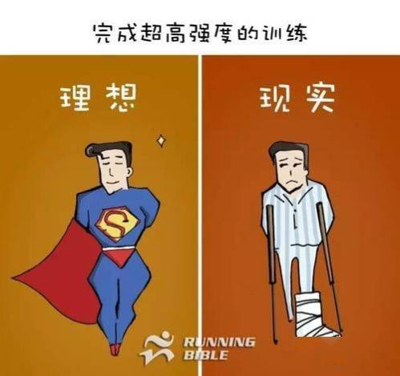


[5/5] question_id : 00000000-4
  category   : Perception & Understanding
  task       : Description
  prompt     : 讲一讲这张图片的内容。
  prediction : 两个角色，一个穿着制服、手握红绳（超级英雄），另一个穿短裤和袜子，分别在背景上站着，中间有“超人”字样。右侧是“超级男人”，左侧是“Alice”。########################################################################################################
  ref_answer : 这张图片展现了完成超高强度的训练之后的理想和现实之间的对比。理想中的样子是超人，而现实中的样子是拄着拐杖残疾的人，运用了夸张的对比，表达出了理想和现实之间的差别，非常的幽默和诙谐，也真实的反映了实际情况。图片下方有一个跑步的图案，旁边写有英文“RUNNING BIBLE”。


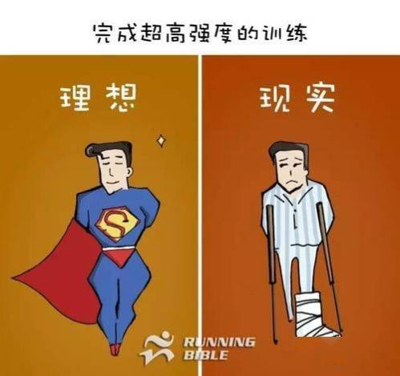

In [6]:
from IPython.display import display, Image as IPImage
from PIL import Image

# ── 将推理结果与原始数据合并，便于对比分析 ────────────────────────────────
# 先将原始数据集建立 question_id -> 原始记录 的索引
ref_map = {}
with open(JSONL_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            item = json.loads(line)
            ref_map[item['question_id']] = item

# ── 可视化前 N 条结果 ─────────────────────────────────────────────────────
N_DISPLAY = 5  # 修改此值可展示更多或更少样本

for idx, result in enumerate(results[:N_DISPLAY]):
    qid  = result['question_id']
    pred = result['predict']
    ref  = ref_map.get(qid, {})

    print(f"{'='*70}")
    print(f"[{idx+1}/{N_DISPLAY}] question_id : {qid}")
    print(f"  category   : {ref.get('category', 'N/A')}")
    print(f"  task       : {ref.get('task', 'N/A')}")
    print(f"  prompt     : {ref.get('prompt', 'N/A')}")
    print(f"  prediction : {pred}")
    print(f"  ref_answer : {ref.get('ref_answer', 'N/A')}")

    # 尝试展示对应图像
    if 'image_path' in ref:
        img_path = os.path.join(IMAGE_ROOT, ref['image_path'])
        if os.path.exists(img_path):
            img = Image.open(img_path).convert('RGB')
            # 限制展示尺寸避免撑大输出
            img.thumbnail((400, 400))
            display(img)
        else:
            print(f"  [图像文件未找到: {img_path}]")
    print()

In [ ]:
# ── 按 task / category 统计样本分布 ──────────────────────────────────────
from collections import Counter

task_counter     = Counter()
category_counter = Counter()

for result in results:
    ref = ref_map.get(result['question_id'], {})
    task_counter[ref.get('task', 'Unknown')]         += 1
    category_counter[ref.get('category', 'Unknown')] += 1

print("Task 分布：")
for task, cnt in task_counter.most_common():
    print(f"  {task:<30} {cnt}")

print("\nCategory 分布：")
for cat, cnt in category_counter.most_common():
    print(f"  {cat:<40} {cnt}")

In [ ]:
# ── 检查推理结果中是否有异常（生成错误或空回复）────────────────────────────
error_results  = [r for r in results if r['predict'].startswith('[') and 'Error' in r['predict']]
empty_results  = [r for r in results if not r['predict'].strip()]

print(f"总样本数   : {len(results)}")
print(f"生成错误数 : {len(error_results)}")
print(f"空回复数   : {len(empty_results)}")

if error_results:
    print("\n示例错误条目：")
    for r in error_results[:3]:
        print(f"  question_id={r['question_id']}  predict={r['predict']}")